# Cyberbully Detection Analysis
`detection.py` converted to a Jupyter notebook.


## Setup and Data Loading


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import re

# load the dataset
df = pd.read_csv('final_hateXplain.csv')


## 1. Dataset Overview


In [2]:
# 1. check the dataset (txt file + overview)
with open('1_dataset_info.txt', 'w') as f:
    # to screen
    print("--- Data Outline ---")
    overview = f"Rows: {df.shape[0]}, Columns: {df.shape[1]}"
    print(overview)

    # to txt file
    f.write("--- Data Overview ---\n")
    f.write(f"Dataset Shape: {df.shape}\n")
    f.write(f"Columns: {df.columns.tolist()}\n")

    f.write("\n --- variable info ---\n")
    var_info = pd.DataFrame({
        "Column": df.columns,
        "Dtype": df.dtypes.values
    })
    print(var_info)
    f.write(var_info.to_string() + "\n\n")

    # check for missing values
    print("\n --- missing values ---")
    f.write("\n --- missing value count ---\n")

    null_counts = df.isnull().sum()
    print(null_counts)
    f.write(null_counts.to_string() + "\n\n")

    # check missing value percentage
    null_pct = (df.isnull().sum() / len(df)) * 100
    print("\n --- missing value percentage ---")
    f.write("\n --- missing value percentage ---\n")
    print(null_pct)
    f.write(null_pct.to_string() + "\n\n")

print('--- variable info recorded in 1_dataset_info.txt ---')


--- Data Outline ---
Rows: 20109, Columns: 7
               Column   Dtype
0             comment  object
1               label  object
2                Race  object
3            Religion  object
4              Gender  object
5  Sexual Orientation  object
6       Miscellaneous  object

 --- missing values ---
comment                   0
label                     0
Race                      0
Religion                  0
Gender                    0
Sexual Orientation        0
Miscellaneous         16576
dtype: int64

 --- missing value percentage ---
comment                0.000000
label                  0.000000
Race                   0.000000
Religion               0.000000
Gender                 0.000000
Sexual Orientation     0.000000
Miscellaneous         82.430752
dtype: float64
--- variable info recorded in 1_dataset_info.txt ---


## 2. Demographic Target Distribution Analysis


variable check: RACE
Race
No_race       13579
African        3769
Arab           1172
Caucasian       802
Asian           400
Hispanic        313
Indigenous       42
Indian           32
Name: count, dtype: int64
------------------------------
variable check: RELIGION
Religion
Nonreligious    15387
Islam            2559
Jewish           1950
Christian         163
Hindu              42
Buddhism            8
Name: count, dtype: int64
------------------------------
variable check: GENDER
Gender
No_gender    16380
Women         2262
Men           1467
Name: count, dtype: int64
------------------------------
variable check: SEXUAL ORIENTATION
Sexual Orientation
No_orientation    17827
Homosexual         2163
Heterosexual        113
Asexual               4
Bisexual              2
Name: count, dtype: int64
------------------------------
variable check: MISCELLANEOUS
Miscellaneous
Other         2017
Refugee       1274
Minority       107
Disability      96
Economic        39
Name: count, dtype: 

/tmp/ipykernel_52438/3709373683.py:112: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


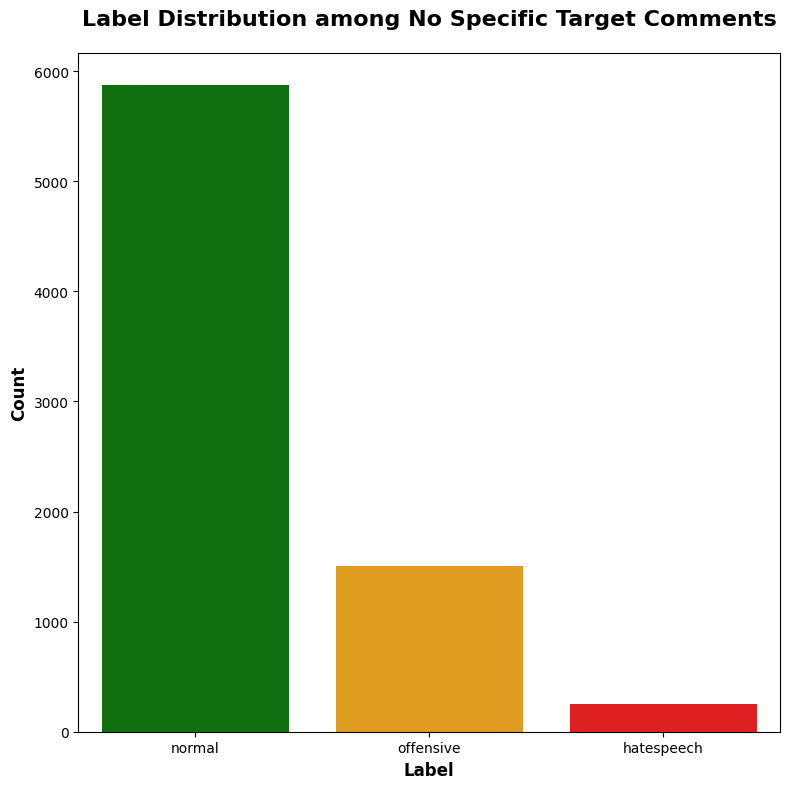

In [47]:
# 2. Demographic (target) distribution anlysis
## check each demographic (target) variable
target_cols = ['Race', 'Religion', 'Gender', 'Sexual Orientation', 'Miscellaneous']

## record to txt file
with open('2_target_variable_check.txt', 'w') as f:
    f.write("--- Target Columns Variable Check ---\n\n")

    for col in target_cols:
        print(f'variable check: {col.upper()}')
        ### print all values and counts in each column
        target_counts = df[col].value_counts()

        print(target_counts)
        print("-" * 30)

        ### write to txt file
        f.write(f'[{col.upper()}]\n')
        f.write(target_counts.to_string() + "\n\n")

print("\n --- Target variable check recorded in 2_target_variable_check.txt --- \n")


non_values = {'Race': 'No_race', 'Religion': 'Nonreligious', 'Gender': 'No_gender',
               'Sexual Orientation': 'No_orientation'}

### pick the rows with no specific target
is_none = df.apply(
    lambda x: all(x[col] == val for col, val in non_values.items()),
    axis=1,
)
non_count = is_none.sum()
non_df = df[is_none]
non_label_counts = non_df['label'].value_counts()
non_label_pct = non_df['label'].value_counts(normalize=True) * 100

print(f"Among total {len(df)} rows, the rows with no specific target for all labels: {non_count}")
print(f"Ratio: {(non_count/len(df)) * 100:.2f}")
print("\n--- Label distribution among all no specific target rows ---")
print(non_label_counts)

with open('3_non_value_analysis.txt', 'w') as f:
    f.write("--- Analysis of rows with all no specific target values ---\n\n")
    f.write(f"Total rows: {len(df)}\n")
    f.write(f"Rows with all no specific target values: {non_count}\n")
    f.write(f"Ratio: {(non_count/len(df)) * 100:.2f}%\n")
    f.write("\n--- Label Distribution ---\n")
    f.write(non_label_counts.to_string() + "\n\n")
    f.write("--- Label Distribution Percentage ---\n")
    for label, pct in non_label_pct.items():
        f.write(f"{label}: {pct:.2f}%\n")

non_summary_table = pd.DataFrame({
    'Label': non_label_counts.index,
    'Count': non_label_counts.values,
    'Percentage': [f'{pct:.2f}%' for pct in non_label_pct.values]
})

fig, ax = plt.subplots(figsize=(8, max(4, len(non_summary_table) * 0.8 + 2)))
ax.axis('off')

summary_text = (
    f'Total rows: {len(df)}\n'
    f'All no(n)_ rows: {non_count}\n'
    f'Ratio: {(non_count/len(df)) * 100:.2f}%'
)
ax.text(
    0.02,
    0.98,
    summary_text,
    transform=ax.transAxes,
    fontsize=11,
    fontweight='bold',
    va='top',
)

non_table = ax.table(
    cellText=non_summary_table.values,
    colLabels=non_summary_table.columns,
    loc='center',
    colLoc='center',
    cellLoc='center',
    bbox=[0, 0.05, 1, 0.65],
)
non_table.auto_set_font_size(False)
non_table.set_fontsize(10)

for (row, col_idx), cell in non_table.get_celld().items():
    if row == 0:
        cell.set_text_props(fontweight='bold')

plt.title(
    "All No-Specific-Target Raws Analysis",
    fontsize=16,
    fontweight='bold',
    pad=20
)
plt.tight_layout()
plt.savefig('3_non_value_analysis.png', bbox_inches='tight', dpi=300)
plt.close()

print("\n --- Analysis of rows with all 'no(n)_' values recorded in 3_non_value_analysis.txt --- \n")

## bar plot by label
lab_color = {
    'hatespeech': 'red',
    'offensive': 'orange',
    'normal': 'green'
}
plt.figure(figsize=(8, 8))

sns.barplot(
    x=non_label_counts.index,     
    y=non_label_counts.values,
    palette=lab_color,
    legend=False
)

plt.title('Label Distribution among No Specific Target Comments', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Label', fontsize=12, fontweight='bold')
plt.ylabel('Count', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('3_non_label_distribution.png', bbox_inches='tight', dpi=300)
plt.show()


## 3. Target Distribution Excluding No Specific Groups


--- Plotting target variable distributions (excluding "no(n)_" values) ---

>>> RACE (total actual target data: 6530)
Race
African       3769
Arab          1172
Caucasian      802
Asian          400
Hispanic       313
Indigenous      42
Indian          32
Name: count, dtype: int64


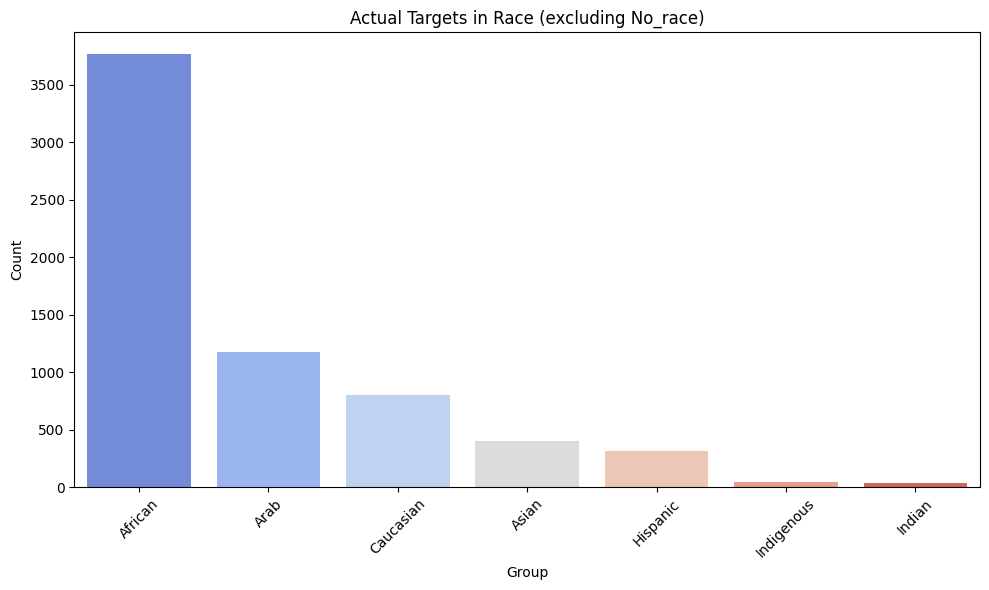


>>> RELIGION (total actual target data: 4722)
Religion
Islam        2559
Jewish       1950
Christian     163
Hindu          42
Buddhism        8
Name: count, dtype: int64


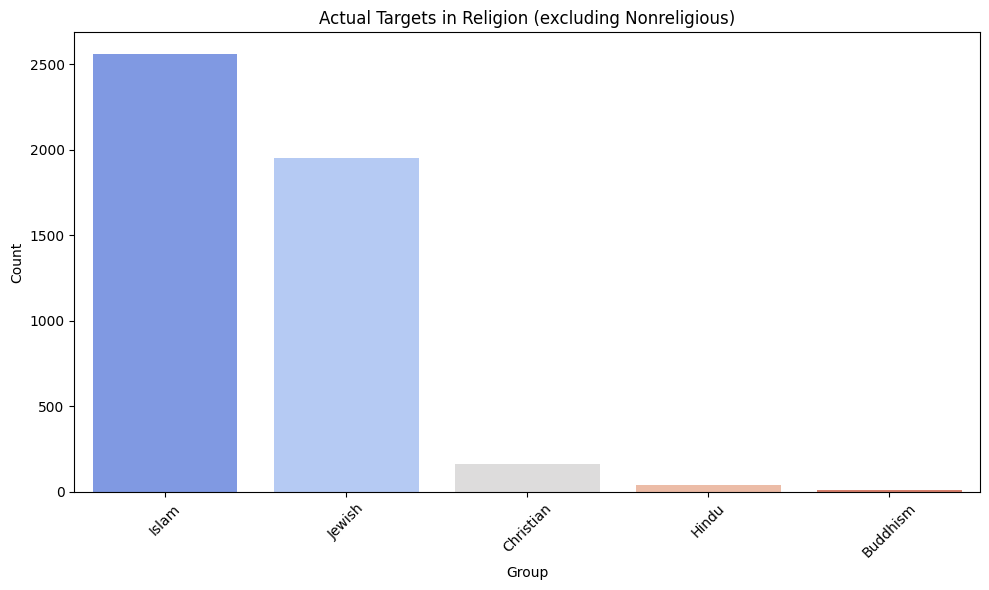


>>> GENDER (total actual target data: 3729)
Gender
Women    2262
Men      1467
Name: count, dtype: int64


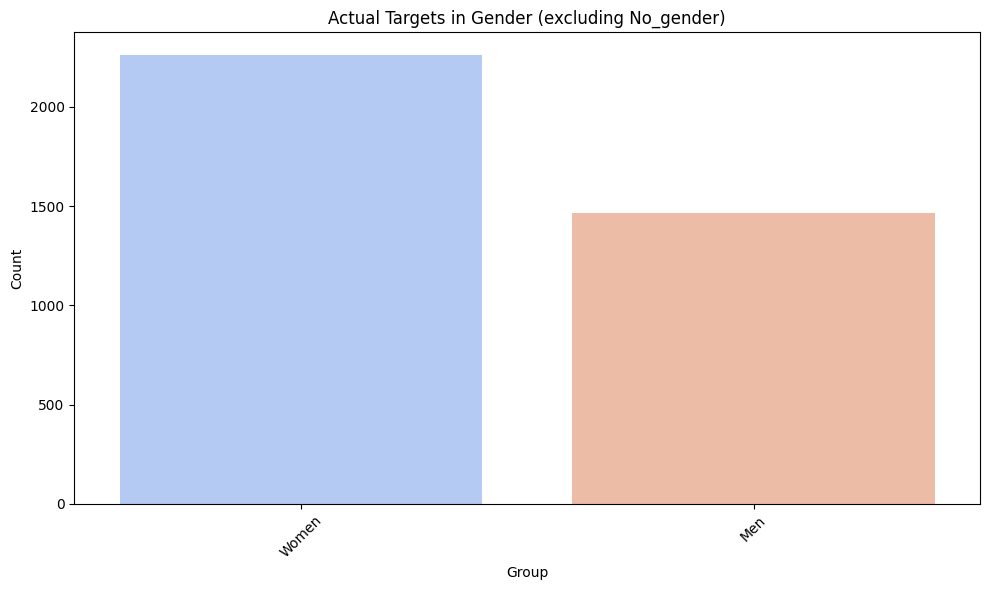


>>> SEXUAL ORIENTATION (total actual target data: 2282)
Sexual Orientation
Homosexual      2163
Heterosexual     113
Asexual            4
Bisexual           2
Name: count, dtype: int64


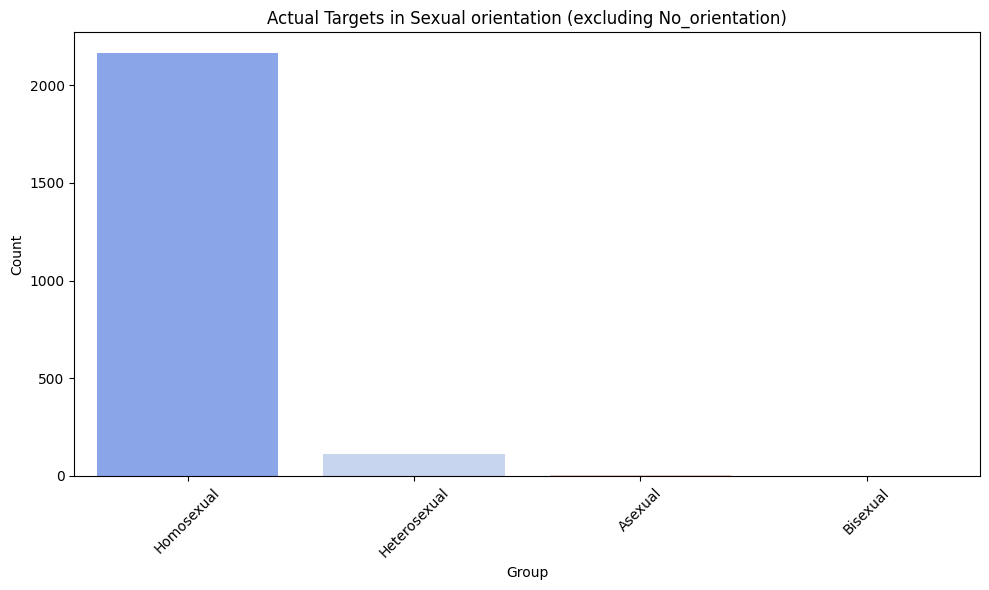

Miscellaneous
Other         2017
Refugee       1274
Minority       107
Disability      96
Economic        39
Name: count, dtype: int64


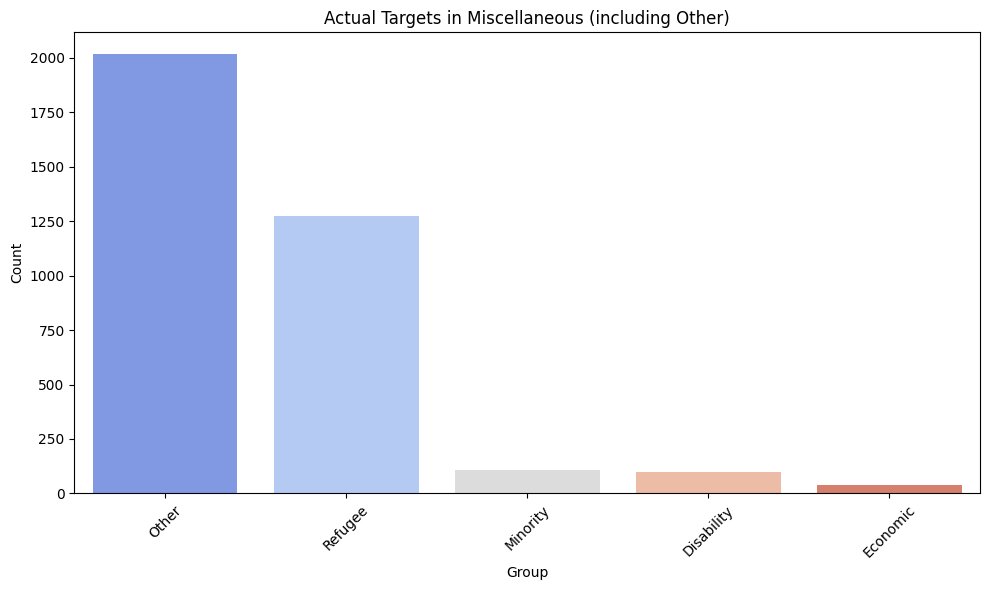


--- Filtered Target Distribution Summary and Barplot saved ---


In [54]:
# 3. check each target distribution except for "no(n)_" values
### filter no(n) value for each target
none_map = {
    'Race': 'No_race',
    'Religion': 'Nonreligious',
    'Gender': 'No_gender',
    'Sexual Orientation': 'No_orientation'
}

### plot distribution for each target column and save to file
print('--- Plotting target variable distributions (excluding "no(n)_" values) ---')

with open('4_filtered_target_distribution_analysis.txt', 'w') as f:
    for col, none_val in none_map.items():
        filtered_df = df[df[col] != none_val]
        counts = filtered_df[col].value_counts()

        print(f'\n>>> {col.upper()} (total actual target data: {len(filtered_df)})')
        print(counts)

        ### write to txt file
        f.write(f'[{col.upper()}] Distribution (excluding "no(n)_" values)\n')
        f.write(counts.to_string() + '\n\n')

        ### visualization: bar plot using matplotlib & seaborn (for each column)
        ### save to (4_dist_{col}.png)
        if not counts.empty:
            plt.figure(figsize=(10, 6))
            sns.barplot(
                x=counts.index,
                y=counts.values,
                hue=counts.index,
                palette='coolwarm',
                legend=False,
            )
            plt.title(f'Actual Targets in {col.capitalize()} (excluding {none_val})')
            plt.xlabel('Group')
            plt.ylabel('Count')
            plt.xticks(rotation=45)
            plt.tight_layout()
            plt.savefig(f'4_filtered_dist_{col}.png')
            plt.show()

misc_counts = df['Miscellaneous'].value_counts()
print(misc_counts)

with open('4_filtered_target_distribution_analysis.txt', 'a') as f:
    f.write('[MISCELLANEOUS] Distribution\n')
    f.write(misc_counts.to_string() + '\n\n')

plt.figure(figsize=(10, 6))
sns.barplot(
    x=misc_counts.index,
    y=misc_counts.values,
    hue=misc_counts.index,
    palette='coolwarm',
    legend=False,
)
plt.title('Actual Targets in Miscellaneous (including Other)')
plt.xlabel('Group')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('4_filtered_dist_Miscellaneous.png')
plt.show()
        
print('\n--- Filtered Target Distribution Summary and Barplot saved ---')


## 4. Label Distribution Excluding No Specific Target Comments


--- Checking label distribution excluding no specific target comments ---
label
hatespeech    6234
offensive     4301
normal        1945
Name: count, dtype: int64


<Figure size 800x800 with 0 Axes>

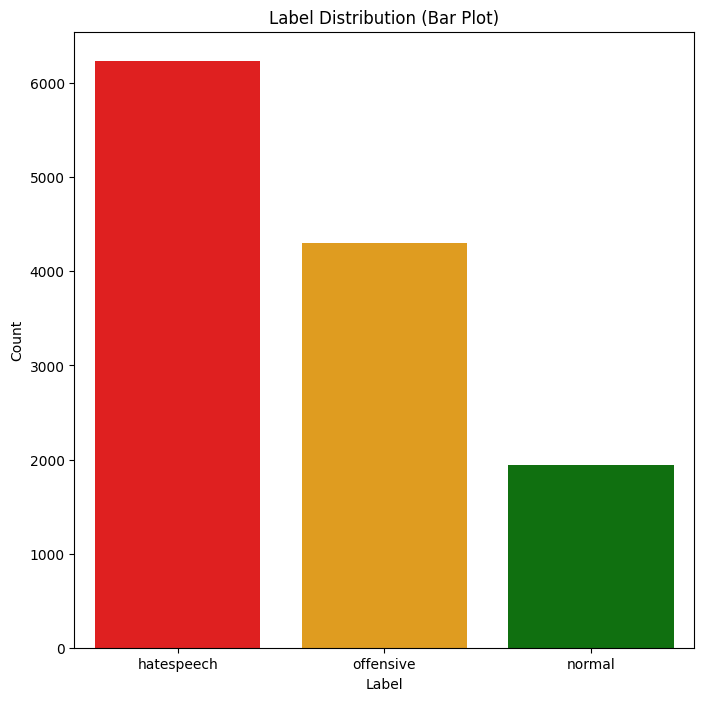

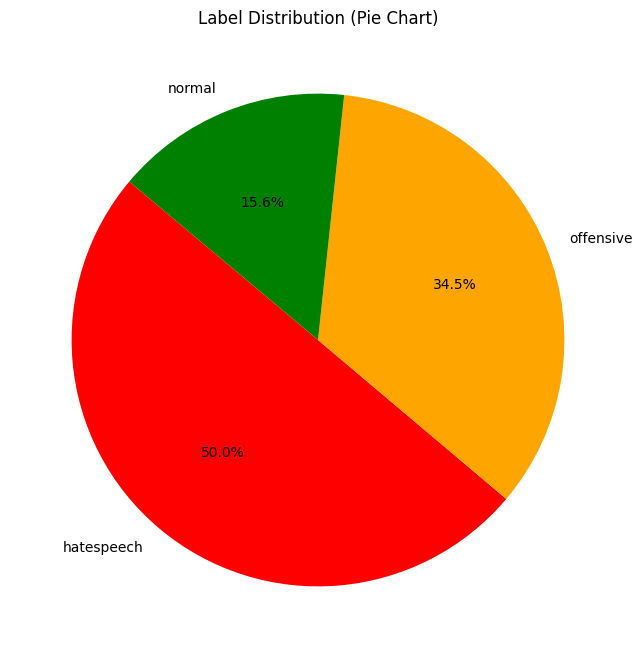

--- Label Distribution Summary and Visualizations saved ---


In [ ]:
# 4. check label distribution except for no specific target comments
## check frequency
print('--- Checking label distribution excluding no specific target comments ---')

targeted_df = df[~is_none]

targeted_label_count = targeted_df['label'].value_counts()
targeted_label_pct = targeted_df['label'].value_counts(normalize=True) * 100
print(targeted_label_count)

## save to txt file
with open('5_label_distribution.txt', 'w') as f:
    f.write("--- Label Distribution ---\n\n")
    f.write(targeted_label_count.to_string() + '\n\n')
    # add ratio (%)
    targeted_label_pct = targeted_df['label'].value_counts(normalize=True) * 100
    f.write('--- Percentage Table --- \n')
    for label, pct in targeted_label_pct.items():
        f.write(f'{label}: {pct:.2f}%\n')

## visualize 1: pie chart
plt.figure(figsize=(8, 8))
### label color: Hate speech (Red), Offensive (Orange), Normal (Green)
label_color = {
    'hatespeech': 'red',
    'offensive': 'orange',
    'normal': 'green'
    }

### draw bar plot & pie chart and save to file (5_label_distribution_pie.png)
plt.figure(figsize=(8, 8))
sns.barplot(
    x=targeted_label_count.index,
    y=targeted_label_count.values,
    hue=targeted_label_count.index,
    palette=label_color,
    legend=False,
)
plt.title('Label Distribution w/ No Specific Target Comments (Bar Plot)')
plt.xlabel('Label')
plt.ylabel('Count')
plt.savefig('5_label_distribution_bar.png')

plt.figure(figsize=(8, 8))
plt.pie(targeted_label_count.values, labels=targeted_label_count.index,
        colors=[label_color[label] for label in targeted_label_count.index], autopct='%1.1f%%', startangle=140)
plt.title('Label Distribution w/ no specific tartget comments (Pie Chart)')
plt.savefig('5_label_distribution_pie.png')
plt.show()

print('--- Label Distribution Summary and Visualizations saved ---')




## 5. Label Distribution for Each Target


--- Checking label distribution for each target ---

>>> 100% stacked bar chart for each target (including 'no(n)_' values)
Race ratio table image
Race stacked bar chart


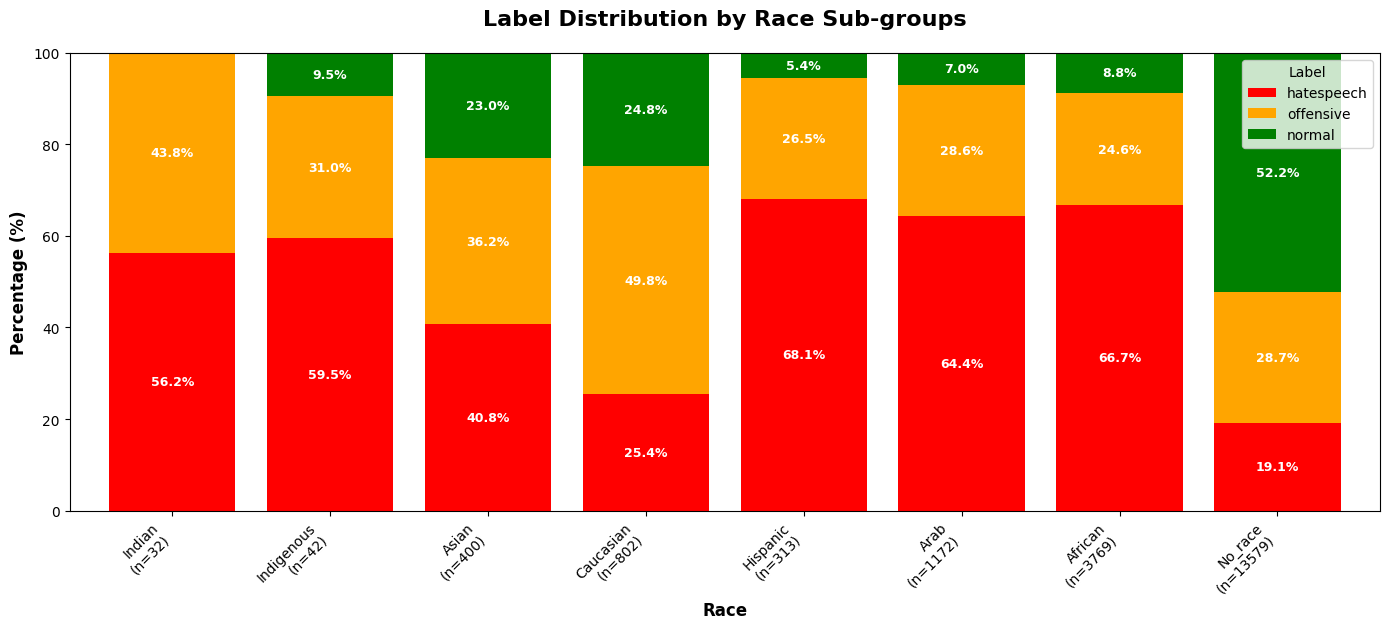

--- Label distribution ratio table saved as 6_RatioTable_Race.png ---
--- Label Distribution by Target Subgroups saved as 6_StackedBar_Race.png ---
Religion ratio table image
Religion stacked bar chart


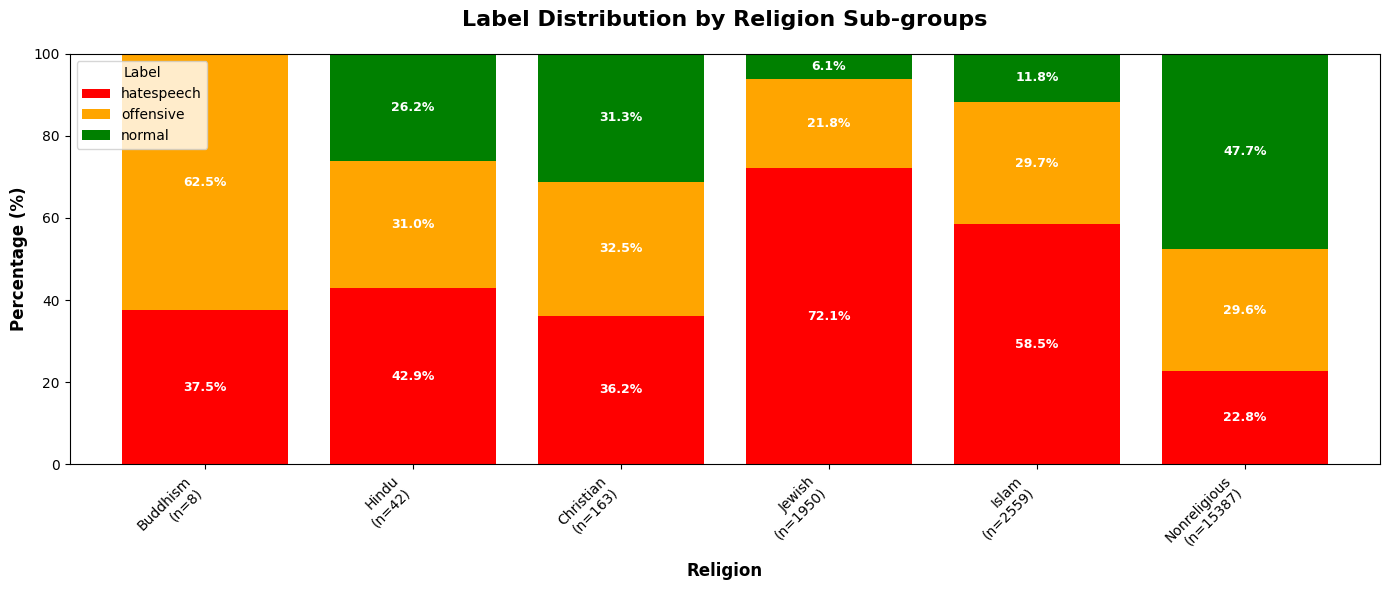

--- Label distribution ratio table saved as 6_RatioTable_Religion.png ---
--- Label Distribution by Target Subgroups saved as 6_StackedBar_Religion.png ---
Gender ratio table image
Gender stacked bar chart


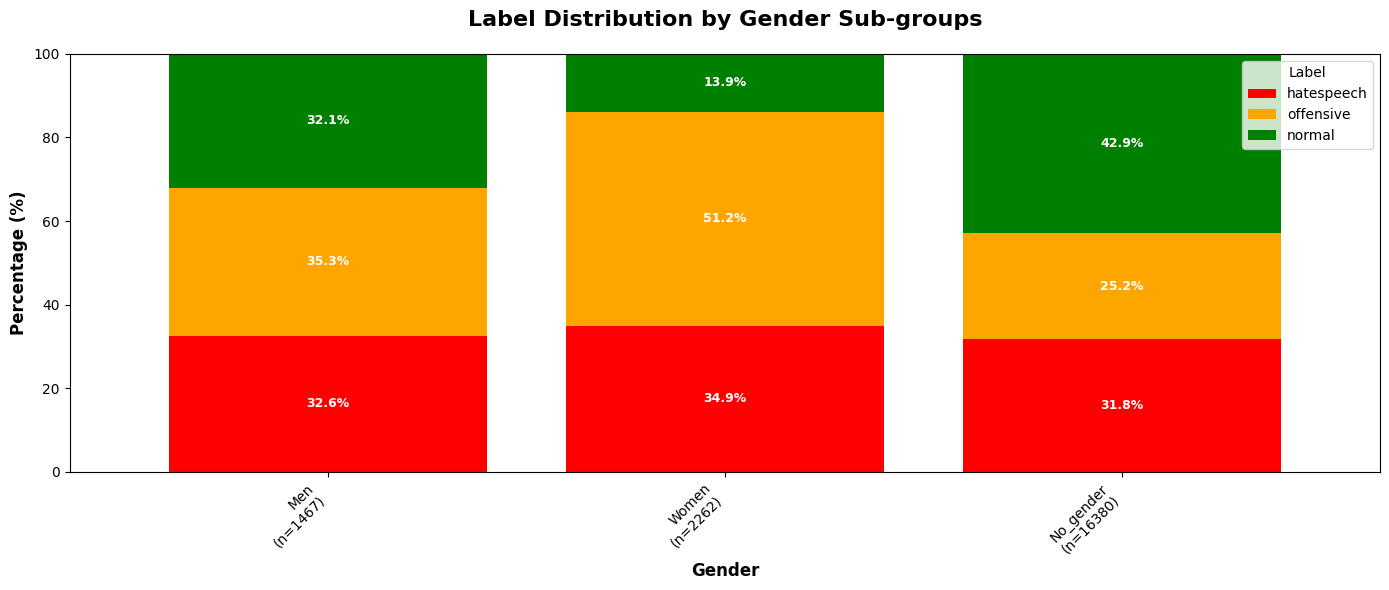

--- Label distribution ratio table saved as 6_RatioTable_Gender.png ---
--- Label Distribution by Target Subgroups saved as 6_StackedBar_Gender.png ---
Sexual orientation ratio table image
Sexual orientation stacked bar chart


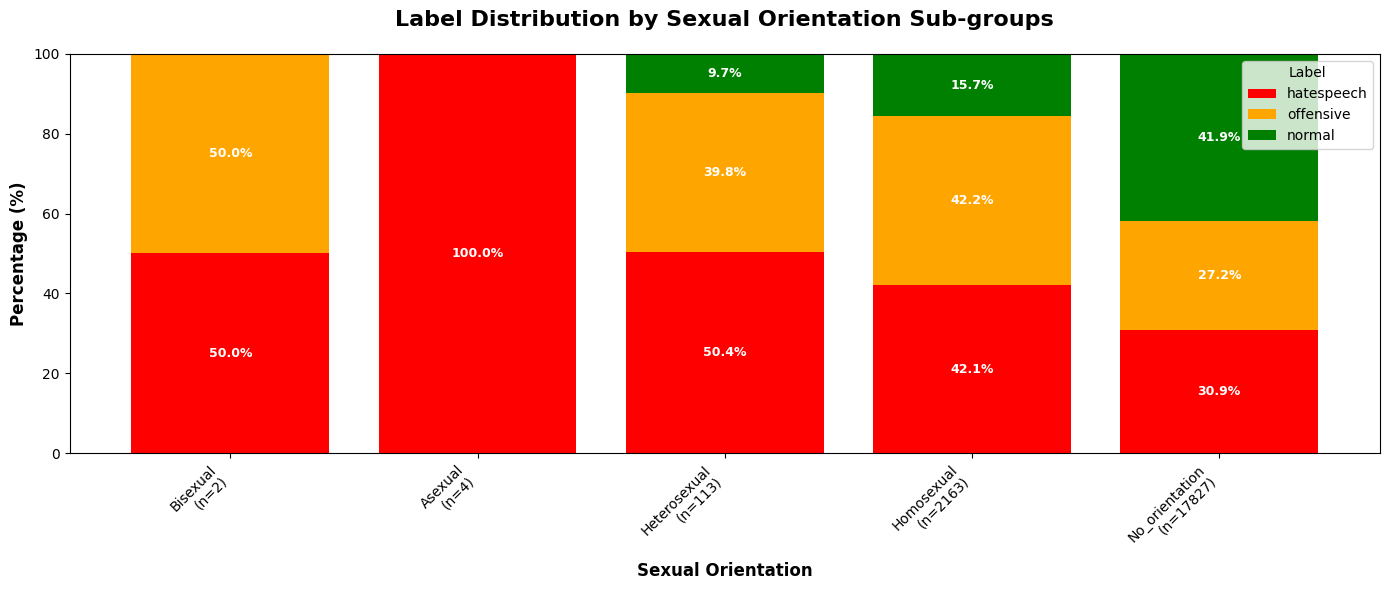

--- Label distribution ratio table saved as 6_RatioTable_Sexual Orientation.png ---
--- Label Distribution by Target Subgroups saved as 6_StackedBar_Sexual Orientation.png ---
Miscellaneous ratio table image
Miscellaneous stacked bar chart


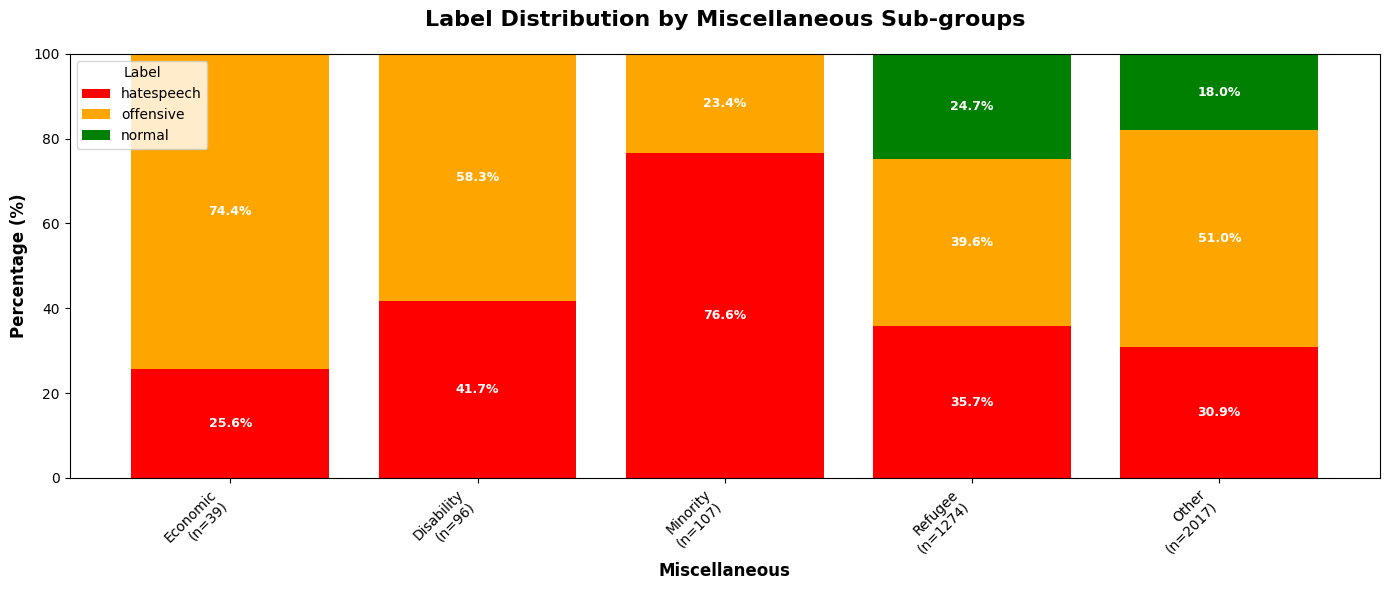

--- Label distribution ratio table saved as 6_RatioTable_Miscellaneous.png ---
--- Label Distribution by Target Subgroups saved as 6_StackedBar_Miscellaneous.png ---
--- Label distribution ratio tables recorded in 6_label_distribution_ratio_tables.txt ---


In [ ]:
# 5. Label Distribution for each Target
print('--- Checking label distribution for each target ---')

## 'no(n)_' values included
target_cols = ['Race', 'Religion', 'Gender', 'Sexual Orientation', 'Miscellaneous']

print("\n>>> 100% stacked bar chart for each target (including 'no(n)_' values)")

with open('6_label_distribution_ratio_tables.txt', 'w') as f:
    f.write("--- Label Distribution Ratio Tables by Target ---\n\n")

    for col in target_cols:
        ### cross-tabulation of label and target column
        counts = pd.crosstab(df[col], df['label'])

        ### calculate percentage using row-wise normalization
        pct = pd.crosstab(df[col], df['label'], normalize='index') * 100
        sort_labels = [label for label in ['hatespeech', 'offensive', 'normal'] if label in counts.columns]
        if sort_labels:
            counts = counts.sort_values(by=sort_labels, ascending=True)
            pct = pct.loc[counts.index]

        pct_formatted = pct.copy()
        for label in pct_formatted.columns:
            pct_formatted[label] = pct_formatted[label].map(lambda value: f'{value:.2f}%')

        f.write(f'[{col.upper()}]\n')
        f.write(pct_formatted.to_string())
        f.write('\n\n')

        print(f'{col.capitalize()} ratio table image')

        fig, ax = plt.subplots(figsize=(10, max(4, len(pct_formatted) * 0.6 + 1.5)))
        ax.axis('off')
        ratio_table = ax.table(
            cellText=pct_formatted.values,
            colLabels=pct_formatted.columns,
            rowLabels=pct_formatted.index,
            loc='center',
            colLoc='center',
        )
        ratio_table.auto_set_font_size(False)
        ratio_table.set_fontsize(10)

        for (row, col_idx), cell in ratio_table.get_celld().items():
            if row == 0 or col_idx == -1:
                cell.set_text_props(fontweight='bold')

        plt.title(
            f'Label Distribution Ratio Table: {col}',
            fontsize=16,
            fontweight='bold',
            pad=20,
        )
        plt.tight_layout()
        plt.savefig(f'6_RatioTable_{col}.png', bbox_inches='tight', dpi=300)
        plt.close()

        print(f'{col.capitalize()} stacked bar chart')

        plot_order = ['hatespeech', 'offensive', 'normal']
        plot_cols = [label for label in plot_order if label in pct.columns]
        pct_plot = pct[plot_cols]

        color_map = {
            'hatespeech': 'red',
            'offensive': 'orange',
            'normal': 'green',
        }

        fig, ax = plt.subplots(figsize=(14, max(6, len(pct_plot) * 0.8)))
        pct_plot.plot(
            kind='bar',
            stacked=True,
            color=[color_map[label] for label in plot_cols],
            ax=ax,
            width=0.8,
        )

        for container, label in zip(ax.containers, plot_cols):
            labels = []
            for value in pct_plot[label]:
                labels.append(f'{value:.1f}%' if value >= 5 else '')
            ax.bar_label(container, labels=labels, label_type='center', fontsize=9, color='white', fontweight='bold')

        totals = counts.sum(axis=1)
        tick_labels = [f'{group}\n(n={totals[group]})' for group in pct_plot.index]
        ax.set_xticks(range(len(pct_plot.index)))
        ax.set_xticklabels(tick_labels, rotation=45, ha='right')
        ax.set_ylim(0, 100)
        ax.set_ylabel('Percentage (%)', fontsize=12, fontweight='bold')
        ax.set_xlabel(col, fontsize=12, fontweight='bold')
        ax.set_title(
            f'Label Distribution by {col} Sub-groups',
            fontsize=16,
            fontweight='bold',
            pad=20,
        )
        ax.legend(title='Label')
        plt.tight_layout()
        plt.savefig(f'6_StackedBar_{col}.png', bbox_inches='tight', dpi=300)
        plt.show()

        print(f'--- Label distribution ratio table saved as 6_RatioTable_{col}.png ---')
        print(f'--- Label Distribution by Target Subgroups saved as 6_StackedBar_{col}.png ---')

print('--- Label distribution ratio tables recorded in 6_label_distribution_ratio_tables.txt ---')


## 6. Linguistic Features by Label


--- Checking comment length and emoji distribution by label ---
            count    mean  median  min  max
label                                      
hatespeech   6484  134.71   121.0    8  526
normal       7818  126.20   107.0   10  376
offensive    5807  120.87   102.0    9  354

--- Emoji count by label ---
emoji_exists  False  True 
label                     
hatespeech     6269    215
normal         7196    622
offensive      5465    342


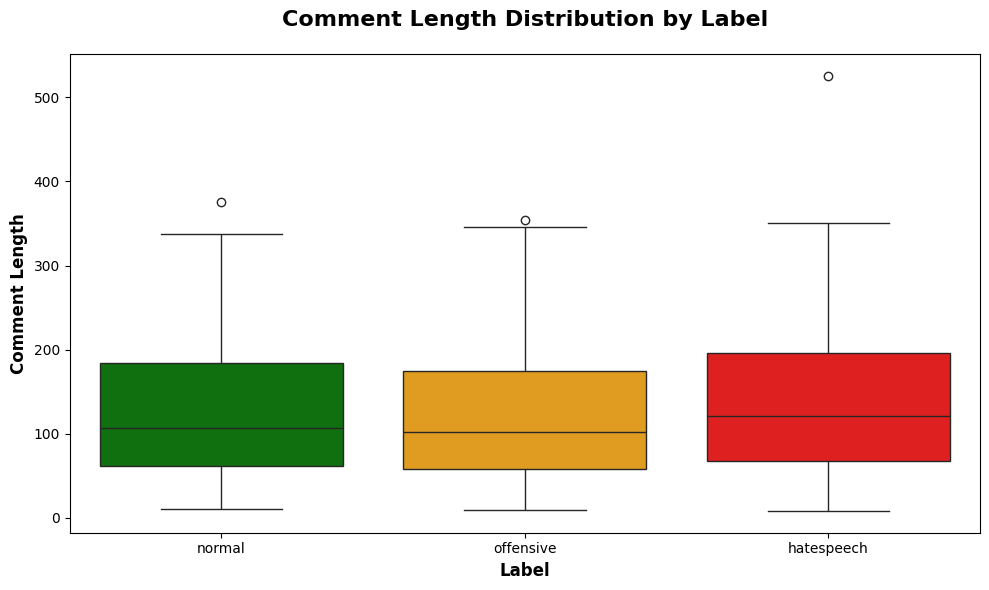

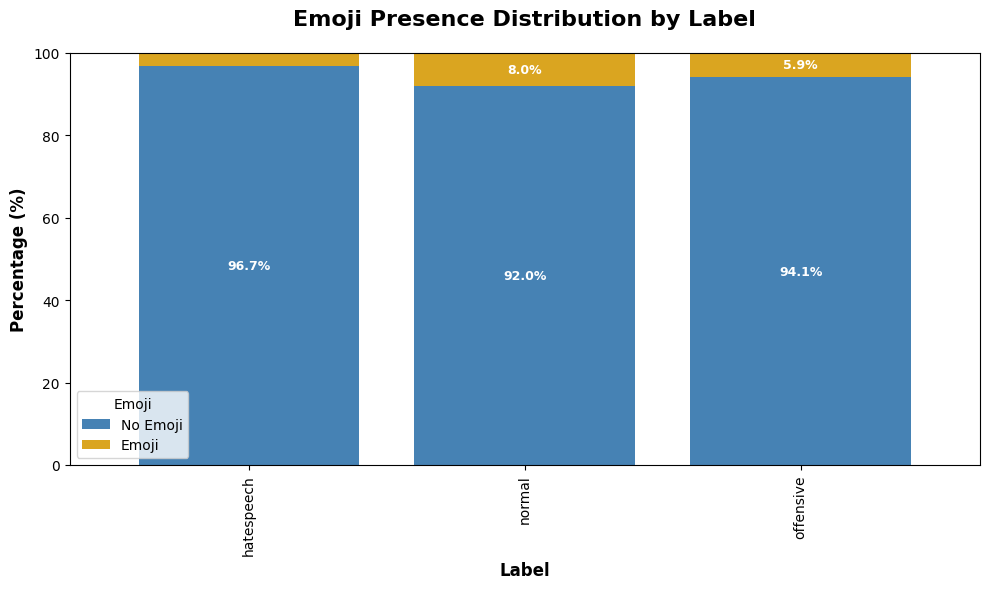

--- Linguistic feature analysis recorded in 7_linguistic_feature_analysis.txt ---
--- Linguistic feature summary table saved as 7_linguistic_feature_analysis.png ---


In [ ]:
# 6. check linguistic features by label
## check text length distribution by label
df['text_len'] = df['comment'].str.len()

## check emoji includedness
## True/False using unicode
def has_emoji(text):
    emoji_pattern = re.compile("["
        u"\U0001f600-\U0001f64f"  # emoticons
        u"\U0001f300-\U0001f5ff"  # symbols & pictographs
        u"\U0001f680-\U0001f6ff"  # transport & map symbols
        u"\U0001f1e0-\U0001f1ff"  # flags (iOS)
        "]+", flags=re.UNICODE)
    return bool(emoji_pattern.search(str(text)))

df['emoji_exists'] = df['comment'].apply(has_emoji)

print('--- Checking comment length and emoji distribution by label ---')

length_summary = df.groupby('label')['text_len'].agg(['count', 'mean', 'median', 'min', 'max']).round(2)
emoji_counts = pd.crosstab(df['label'], df['emoji_exists'])
emoji_pct = pd.crosstab(df['label'], df['emoji_exists'], normalize='index') * 100

with open('7_linguistic_feature_analysis.txt', 'w') as f:
    f.write("--- Comment Length and Emoji Distribution by Label ---\n\n")
    f.write("[COMMENT LENGTH SUMMARY]\n")
    f.write(length_summary.to_string())
    f.write("\n\n[EMOJI COUNT]\n")
    f.write(emoji_counts.to_string())
    f.write("\n\n[EMOJI PERCENTAGE]\n")
    emoji_pct_formatted = emoji_pct.copy()
    for col in emoji_pct_formatted.columns:
        emoji_pct_formatted[col] = emoji_pct_formatted[col].map(lambda value: f'{value:.2f}%')
    f.write(emoji_pct_formatted.to_string())
    f.write("\n")

print(length_summary)
print("\n--- Emoji count by label ---")
print(emoji_counts)

length_table = length_summary.reset_index()
length_table.columns = ['Label', 'Count', 'Mean', 'Median', 'Min', 'Max']
length_table[['Mean', 'Median', 'Min', 'Max']] = length_table[['Mean', 'Median', 'Min', 'Max']].astype(str)

emoji_table = emoji_counts.reset_index().copy()
emoji_table.columns = ['Label'] + ['No Emoji' if value is False else 'Emoji' for value in emoji_counts.columns]
emoji_table['Emoji %'] = emoji_pct.get(True, pd.Series(0, index=emoji_pct.index)).round(2).astype(str) + '%'
emoji_table['No Emoji %'] = emoji_pct.get(False, pd.Series(0, index=emoji_pct.index)).round(2).astype(str) + '%'
emoji_table = emoji_table[['Label', 'No Emoji', 'Emoji', 'No Emoji %', 'Emoji %']]

fig, axes = plt.subplots(2, 1, figsize=(12, 10))

axes[0].axis('off')
length_png_table = axes[0].table(
    cellText=length_table.values,
    colLabels=length_table.columns,
    loc='center',
    cellLoc='center',
    colLoc='center',
)
length_png_table.auto_set_font_size(False)
length_png_table.set_fontsize(10)
for (row, col_idx), cell in length_png_table.get_celld().items():
    if row == 0:
        cell.set_text_props(fontweight='bold')
axes[0].set_title('Comment Length Summary by Label', fontsize=15, fontweight='bold', pad=12)

axes[1].axis('off')
emoji_png_table = axes[1].table(
    cellText=emoji_table.values,
    colLabels=emoji_table.columns,
    loc='center',
    cellLoc='center',
    colLoc='center',
)
emoji_png_table.auto_set_font_size(False)
emoji_png_table.set_fontsize(10)
for (row, col_idx), cell in emoji_png_table.get_celld().items():
    if row == 0:
        cell.set_text_props(fontweight='bold')
axes[1].set_title('Emoji Presence Summary by Label', fontsize=15, fontweight='bold', pad=12)

plt.tight_layout()
plt.savefig('7_linguistic_feature_analysis.png', bbox_inches='tight', dpi=300)
plt.close()

plt.figure(figsize=(10, 6))
sns.boxplot(x='label', y='text_len', data=df, hue='label', palette=label_color, legend=False)
plt.title('Comment Length Distribution by Label', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Label', fontsize=12, fontweight='bold')
plt.ylabel('Comment Length', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('7_comment_length_by_label.png', bbox_inches='tight', dpi=300)
plt.show()

emoji_plot = emoji_pct.copy()
emoji_plot.columns = ['No Emoji' if value is False else 'Emoji' for value in emoji_plot.columns]
emoji_plot = emoji_plot.reindex(columns=['No Emoji', 'Emoji'], fill_value=0)

fig, ax = plt.subplots(figsize=(10, 6))
emoji_plot.plot(
    kind='bar',
    stacked=True,
    color=['steelblue', 'goldenrod'],
    ax=ax,
    width=0.8,
)

for container in ax.containers:
    labels = []
    for value in container.datavalues:
        labels.append(f'{value:.1f}%' if value >= 5 else '')
    ax.bar_label(container, labels=labels, label_type='center', fontsize=9, color='white', fontweight='bold')

ax.set_ylim(0, 100)
ax.set_title('Emoji Presence Distribution by Label', fontsize=16, fontweight='bold', pad=20)
ax.set_xlabel('Label', fontsize=12, fontweight='bold')
ax.set_ylabel('Percentage (%)', fontsize=12, fontweight='bold')
ax.legend(title='Emoji')
plt.tight_layout()
plt.savefig('7_emoji_distribution_by_label.png', bbox_inches='tight', dpi=300)
plt.show()

print('--- Linguistic feature analysis recorded in 7_linguistic_feature_analysis.txt ---')
print('--- Linguistic feature summary table saved as 7_linguistic_feature_analysis.png ---')

